In [3]:
import os
print(os.listdir())

['.config', 'netflix_titles(1).csv', 'sample_data']


# 📊 Netflix Data Visualization using Python

In [4]:
file_path = "netflix_titles(1).csv"

with open(file_path, "rb") as f:
    print(f.read(20))

b'show_id,type,title,d'


## Project Overview

This project focuses on visualizing the Netflix dataset using Python. Data visualization helps transform raw data into meaningful charts and graphs, making it easier to identify patterns, trends, and insights. The project uses Pandas, Matplotlib, and Seaborn to create informative visualizations that support data-driven decision-making.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [8]:
df = pd.read_csv("netflix_titles(1).csv", encoding="latin1")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,23-Dec-16,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,20-Dec-18,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,16-Nov-17,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,1-Jan-20,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [11]:
df.shape

(7787, 12)

## Movies vs TV Shows (Bar Chart)

This visualization compares the number of Movies and TV Shows available on Netflix.

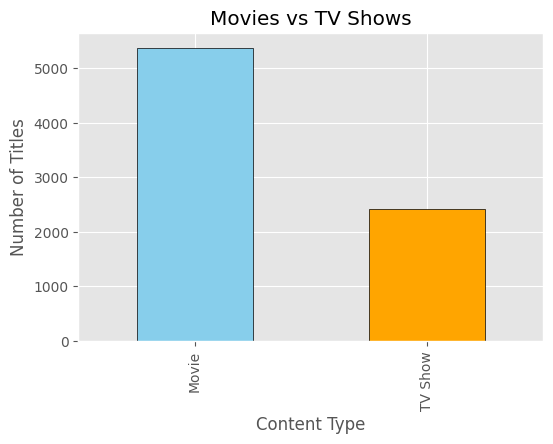

In [12]:
plt.figure(figsize=(6,4))

df['type'].value_counts().plot(
    kind='bar',
    color=['skyblue','orange'],
    edgecolor='black'
)

plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

### Observation

- Movies are available in greater numbers than TV Shows.
- Netflix offers a larger collection of movies than television series.

## Movies vs TV Shows (Pie Chart)

This pie chart shows the percentage distribution of Movies and TV Shows.

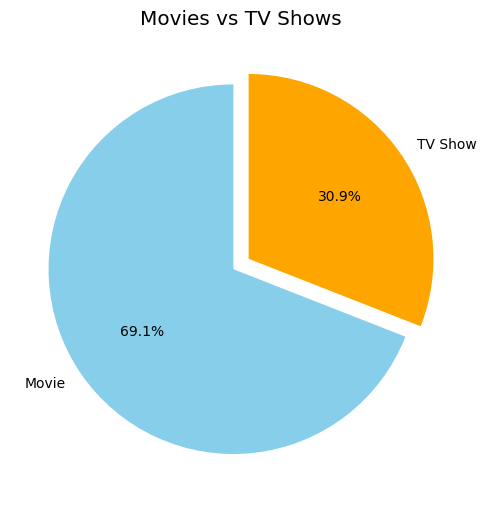

In [13]:
plt.figure(figsize=(6,6))

df['type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05,0.05),
    colors=['skyblue','orange']
)

plt.ylabel("")
plt.title("Movies vs TV Shows")

plt.show()

### Observation

- Movies represent the majority of Netflix content.
- TV Shows occupy a smaller percentage of the catalog.

## Top 10 Countries with Netflix Content

This visualization shows the countries contributing the highest number of Netflix titles.

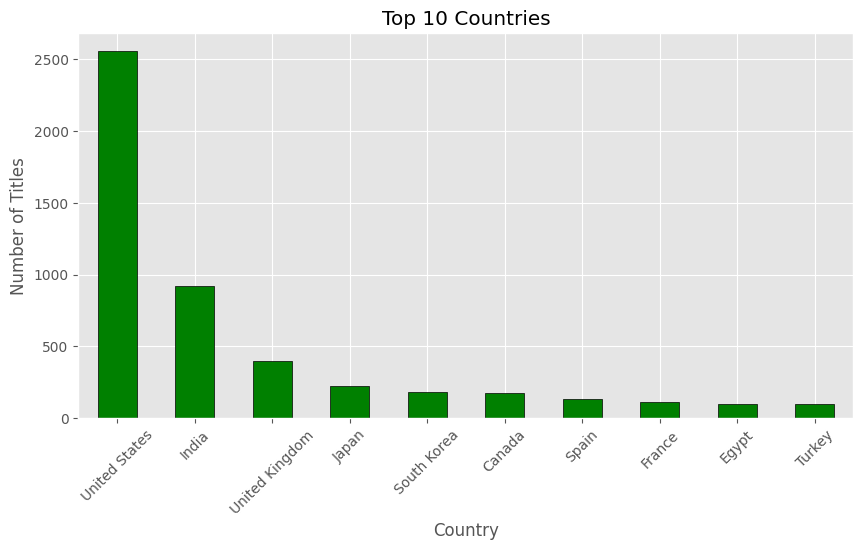

In [14]:
plt.figure(figsize=(10,5))

df['country'].value_counts().head(10).plot(
    kind='bar',
    color='green',
    edgecolor='black'
)

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

### Observation

- The United States contributes the highest number of Netflix titles.
- India and the United Kingdom are among the top contributors.

## Most Common Content Ratings

This chart displays the most frequently occurring content ratings on Netflix.

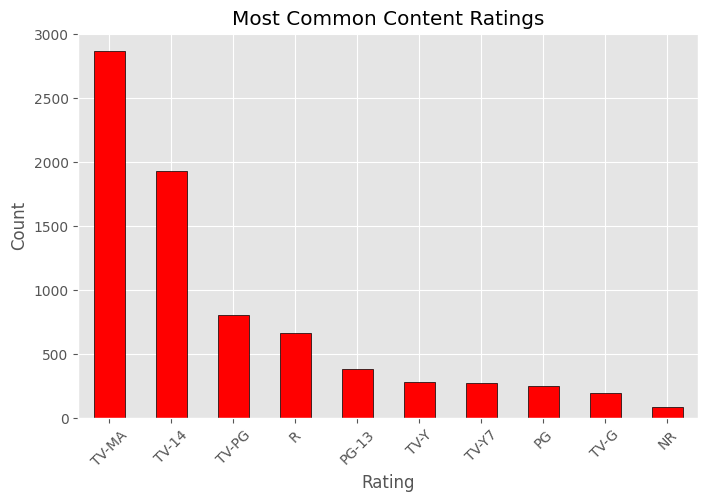

In [15]:
plt.figure(figsize=(8,5))

df['rating'].value_counts().head(10).plot(
    kind='bar',
    color='red',
    edgecolor='black'
)

plt.title("Most Common Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Observation

- TV-MA is the most common content rating.
- Netflix provides content suitable for a variety of audiences.

## Distribution of Release Years

This histogram illustrates how Netflix content is distributed across different release years.

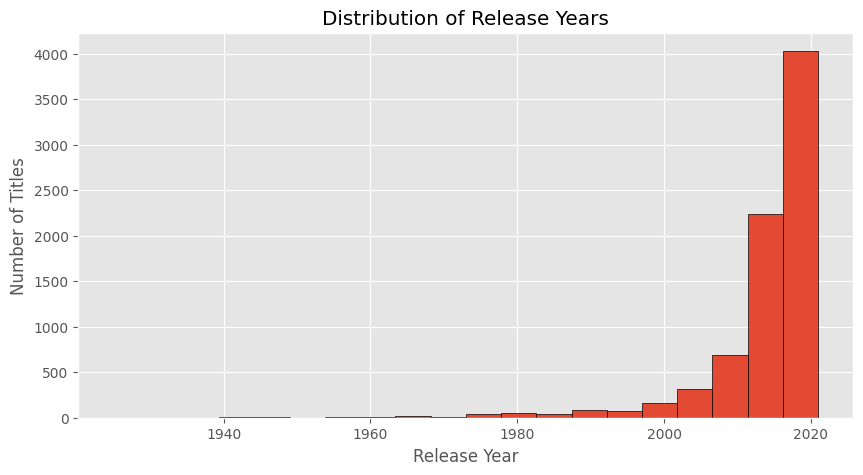

In [16]:
plt.figure(figsize=(10,5))

plt.hist(
    df['release_year'],
    bins=20,
    edgecolor='black'
)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

### Observation

- Most Netflix titles were released after 2010.
- The number of releases increased rapidly in recent years.

## Content Added to Netflix by Year

This line chart shows how many titles were added to Netflix each year.

/tmp/ipykernel_1917/3026276168.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


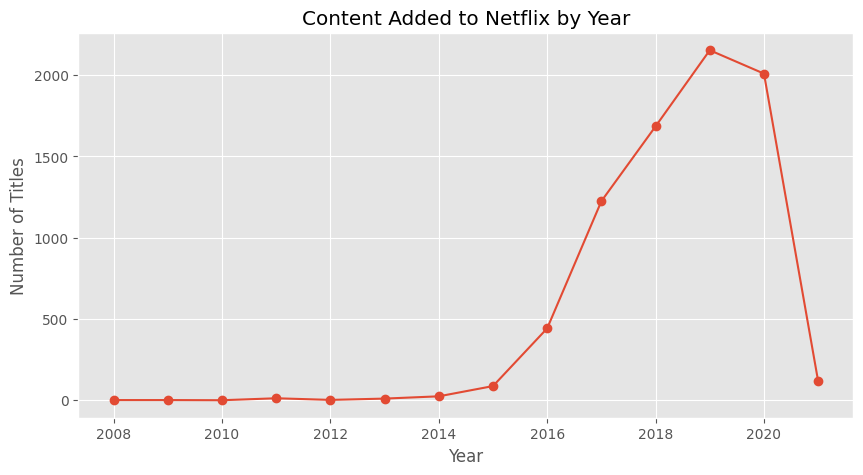

In [17]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(10,5))

df['year_added'].value_counts().sort_index().plot(
    kind='line',
    marker='o'
)

plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

### Observation

- Netflix added a large number of titles after 2015.
- The platform expanded its content library significantly during this period.

## Movie Duration Distribution

This histogram shows the distribution of movie durations available on Netflix.

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1917/1867387024.py:3: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_int'] = movies['duration'].str.extract('(\d+)').astype(float)


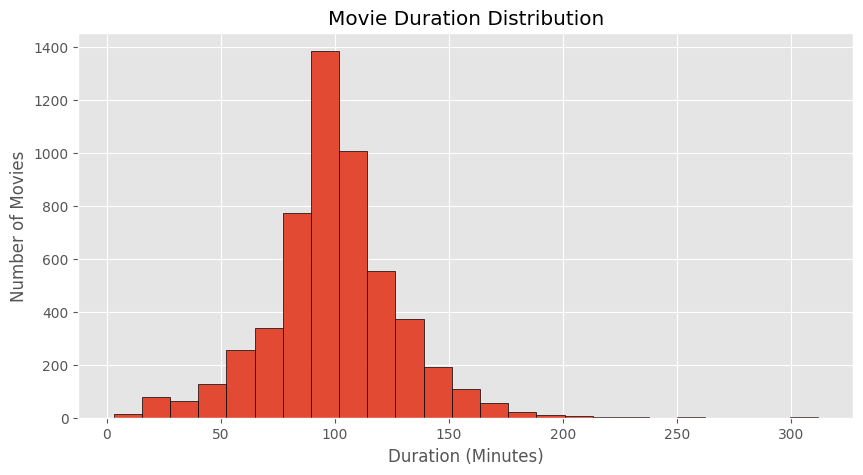

In [18]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration_int'] = movies['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10,5))

plt.hist(
    movies['duration_int'],
    bins=25,
    edgecolor='black'
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

### Observation

- Most movies have a duration between 80 and 120 minutes.
- Very long-duration movies are comparatively fewer.

## Top 10 Most Featured Actors

This chart identifies the actors who appear most frequently in the Netflix dataset.

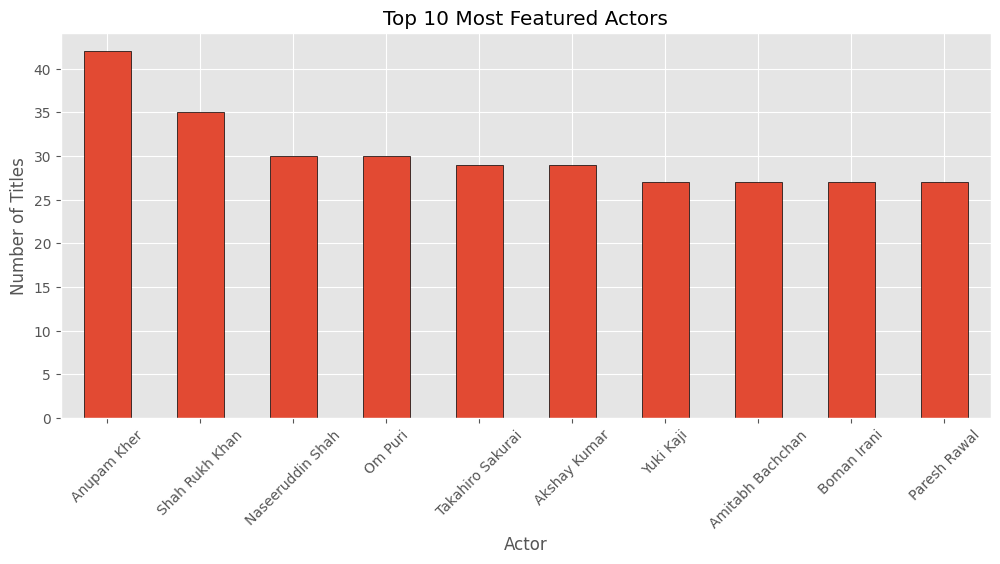

In [19]:
actors = df['cast'].dropna().str.split(', ').explode()

top_actors = actors.value_counts().head(10)

plt.figure(figsize=(12,5))

top_actors.plot(
    kind='bar',
    edgecolor='black'
)

plt.title("Top 10 Most Featured Actors")
plt.xlabel("Actor")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

### Observation

- Some actors appear in multiple Netflix titles.
- These actors have a strong presence across Netflix's content library.

# Key Insights

- Netflix offers more Movies than TV Shows.
- The United States contributes the highest number of titles.
- TV-MA is the most common content rating.
- Most Netflix content was released after 2010.
- Netflix expanded its content library rapidly after 2015.
- Most movies have a duration between 80 and 120 minutes.
- Several actors appear in multiple Netflix titles.

# Conclusion

This project demonstrates how data visualization can transform raw data into meaningful insights. Using Python, Pandas, Matplotlib, and Seaborn, various charts were created to analyze Netflix's content distribution, release trends, ratings, countries, movie durations, and featured actors. These visualizations provide a clear understanding of the dataset and support data-driven decision-making.